In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T
from quanformer.hubconf import *
from quanformer.util.misc import nested_tensor_from_tensor_list
from utils.io_utils import get_files, time_master
from joblib import Parallel, delayed

torch.set_grad_enabled(False);
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


CLASSES = [
    'peak'
]


def rescale_bboxes(out_bbox, size, device):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    img_size_tensor = torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32).to(device)
    b = b * img_size_tensor
    return b


# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098]]


def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)


# standard PyTorch mean-std input image normalization
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


def visualize_decoder(model_path, img_path):

    model = quan_former()
    state_dict = torch.load(model_path, map_location='cpu', weights_only=False)
    model.to(device)
    model.load_state_dict(state_dict["model"])
    model.eval()

    im = Image.open(img_path).convert('RGB')
    img = transform(im).to(device)
    img = nested_tensor_from_tensor_list([img])
    # use lists to store the outputs via up-values
    conv_features, enc_attn_weights, dec_attn_weights = [], [], []

    hooks = [
        model.backbone[-2].register_forward_hook(
            lambda self, input, output: conv_features.append(output)
        ),
        model.transformer.encoder.layers[-1].self_attn.register_forward_hook(
            lambda self, input, output: enc_attn_weights.append(output[1])
        ),
        model.transformer.decoder.layers[-1].multihead_attn.register_forward_hook(
            lambda self, input, output: dec_attn_weights.append(output[1])
        ),
    ]

Encoder attention:       torch.Size([625, 625])
Feature map:             torch.Size([1, 2048, 25, 25])
Reshaped self-attention: torch.Size([25, 25, 25, 25])


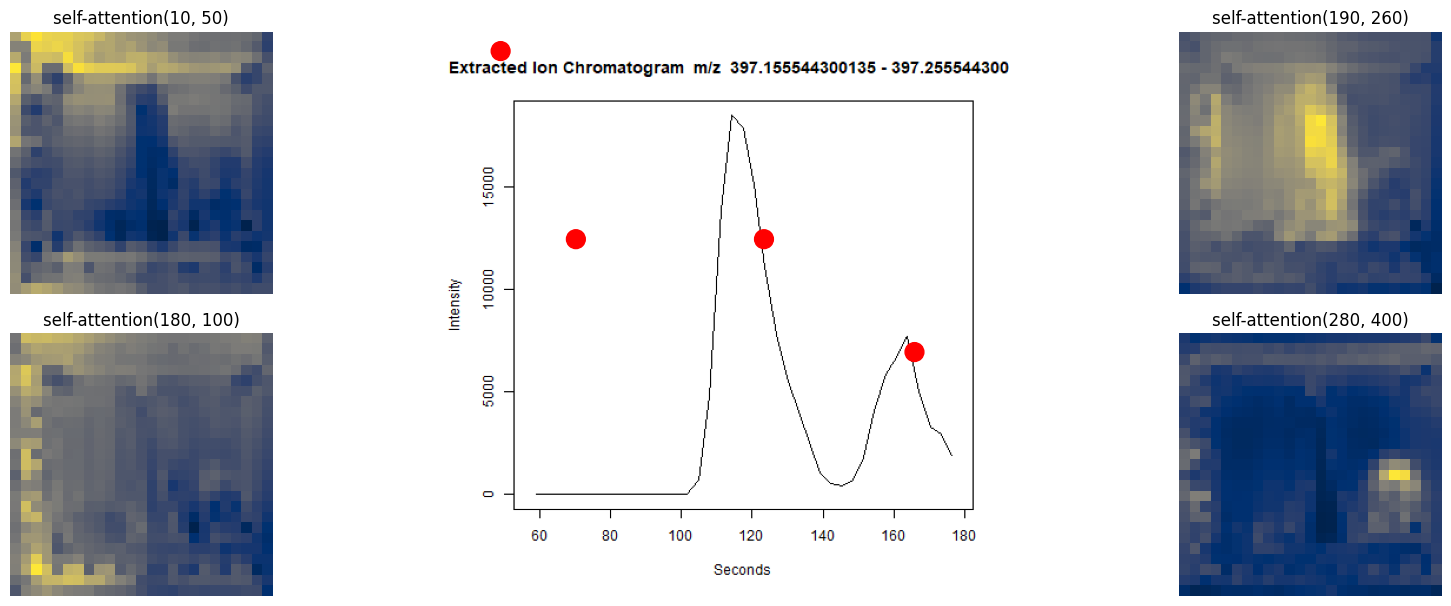

In [6]:
images_path = 'data/117.495_397.205544300135.png'
model_path = "D:/example/checkpoint0029.pth"
visualize_encoder(model_path, images_path)

D:\worksapce\environment\Anaconda\envs\pytorch38\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\worksapce\environment\Anaconda\envs\pytorch38\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


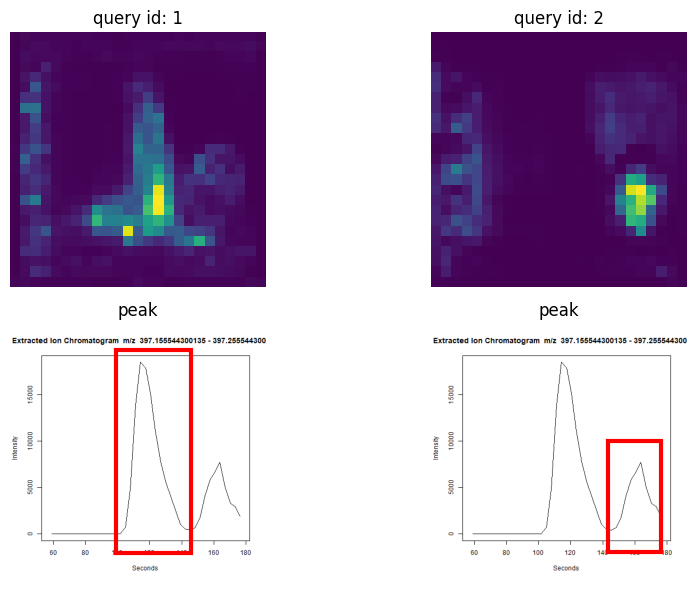

In [7]:
visualize_decoder(model_path, images_path)

D:\worksapce\environment\Anaconda\envs\pytorch38\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\worksapce\environment\Anaconda\envs\pytorch38\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Encoder attention:       torch.Size([625, 625])
Feature map:             torch.Size([1, 2048, 25, 25])
Reshaped self-attention: torch.Size([25, 25, 25, 25])


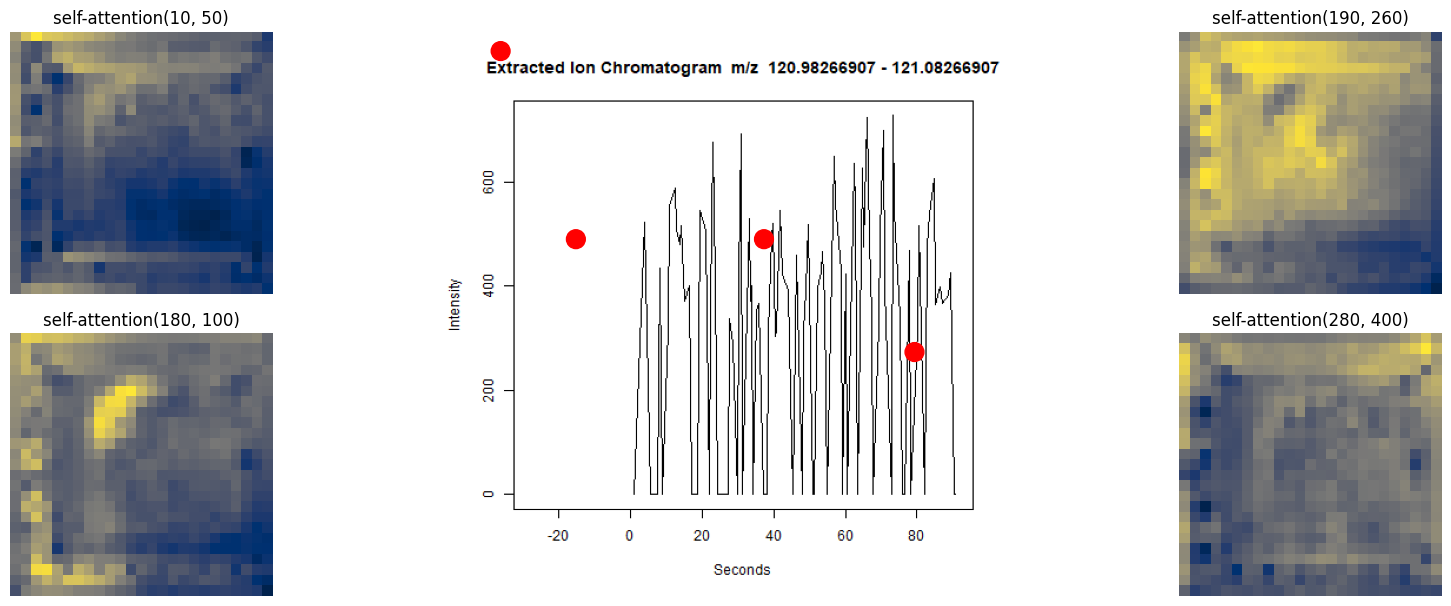

In [4]:
images_path = 'data/31.228_121.03266907.png'
visualize_encoder(model_path, images_path)